In [169]:
# conda activate anndata

import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [170]:
import os

os.getcwd()

'/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/bulk/GTEx/frontal_cortex'

# Prep eigenges

In [171]:
top_mods_df1_Cur = pd.read_csv("data/EA/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed_mergeParam0.95_subsetCutoff68.086_Modules_Curated_EA_top_Qval_mods.csv")

cts = ["CGE Class"]
top_mods_df1_Cur = top_mods_df1_Cur[top_mods_df1_Cur['Cell_type'].isin(cts)]
top_mods_df1_Cur = top_mods_df1_Cur.rename(columns={"Module": "Mod"})

In [172]:
top_mods_df1_FGSEA = pd.read_csv("data/FGSEA/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed_mergeParam0.95_subsetCutoff68.086_Modules_Curated_PC1_FGSEA_top_Qval_mods.csv")

cts = [
    "Micro/PVM", "All GABAergic", "Oligo", "Astro",
    "All Neuronal", "Endo",
    "L6 IT", "L2/3 IT"
]
top_mods_df1_FGSEA = top_mods_df1_FGSEA[top_mods_df1_FGSEA['Cell_type'].isin(cts)]
top_mods_df1_FGSEA.loc[top_mods_df1_FGSEA['Cell_type'] == "OPC", 'Cell_type'] = "Immature OPC"


In [173]:
top_mods_df2_FGSEA = pd.read_csv("data/FGSEA/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed_mergeParam0.93_subsetCutoff68.086_Modules_Curated_PC1_FGSEA_top_Qval_mods.csv")
cts = ["OPC"]
top_mods_df2_FGSEA = top_mods_df2_FGSEA[top_mods_df2_FGSEA['Cell_type'].isin(cts)]

In [174]:
top_mods_df = pd.concat([top_mods_df1_Cur, top_mods_df1_FGSEA, top_mods_df2_FGSEA])

results = []
for idx, row in top_mods_df.iterrows():
    modEig = pd.read_csv(row['ME_path'], index_col=0)[row['Mod']]
    modEig.name = row['Cell_type']
    results.append(modEig)
    
eigengene_df = pd.concat(results, axis=1)

In [175]:
eigengene_df.head()

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Sample,,,,,,,,,,
GTEX.12126.0011.R10b.SM.5BC6T,0.146810,0.095824,-0.042099,-0.070946,-0.035843,-0.040700,-0.020068,-0.049773,0.045241,0.109267
GTEX.1F7RK.0011.R10b.SM.ARU7Y,0.068079,0.085535,0.021223,-0.019596,-0.093812,0.016217,0.066036,0.118367,0.049196,0.008826
GTEX.T5JC.0011.R10A.SM.32PM2,0.012689,0.001989,0.021835,-0.033105,-0.058511,-0.011044,0.035662,-0.018728,0.065645,0.002820
GTEX.WHSE.0011.R10A.SM.EYYVG,0.073536,0.084961,0.074458,-0.008586,0.003785,0.018067,-0.011331,0.004621,-0.023154,0.083886
GTEX.11ZUS.0011.R10b.SM.5BC79,0.027794,0.012384,0.147081,-0.040491,-0.050823,0.478469,-0.061926,-0.062080,-0.048608,0.013112


# Gene expression vs. eigengene

In [176]:
bulk_expr = pd.read_csv("GTEx_frontal_cortex_counts_TMMF_SampleNetworks/All_10-58-02/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed.csv")
bulk_expr.columns.values[0] = "Gene"

In [177]:
# Make sure samples are in the same order

bulk_expr = bulk_expr.set_index("Gene")
common = bulk_expr.columns.intersection(eigengene_df.index)
bulk_expr = bulk_expr[common]
eigengene_df = eigengene_df.loc[common]

In [178]:
eigengene_df.shape

(200, 10)

In [179]:
# Correlate each cell type with gene expression

expr_corr_results = {}
for ct in eigengene_df.columns:
    expr_corr_results[ct] = bulk_expr.T.corrwith(eigengene_df[ct])
    
expr_corr_df = pd.DataFrame(expr_corr_results)

In [180]:
expr_corr_df.sort_values("All Neuronal", ascending=False).head(10)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
DLG3,0.709528,0.841923,-0.019349,0.013993,-0.227879,-0.128760,0.986240,0.754759,0.810542,0.195802
ADD2,0.658479,0.814661,-0.000556,0.040960,-0.211003,-0.113088,0.985687,0.793453,0.781297,0.210593
SMAP2,0.699750,0.835714,0.076540,0.046832,-0.178368,-0.076955,0.983650,0.751156,0.798369,0.215937
RAB6B,0.690386,0.833131,0.030397,0.003478,-0.176850,-0.100993,0.983148,0.743738,0.802630,0.218822
SPATS2,0.655802,0.800459,0.057733,0.029383,-0.183947,-0.076134,0.982968,0.750896,0.803426,0.212211
GNB5,0.697305,0.845314,0.049229,0.017356,-0.149856,-0.076487,0.982939,0.775570,0.784948,0.239366
MAP2K4,0.660316,0.825267,0.028636,0.058589,-0.233930,-0.098147,0.982759,0.791501,0.771473,0.217994
NDRG3,0.663725,0.836523,0.056203,0.056082,-0.184723,-0.072567,0.982756,0.779524,0.759593,0.215162
STXBP1,0.634944,0.804396,-0.006763,0.022965,-0.245999,-0.138165,0.982309,0.799365,0.757398,0.142377


In [181]:
expr_corr_df.to_csv("data/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed_ct_eigengenes_kME.csv")

# Cluster eigengenes by correlation

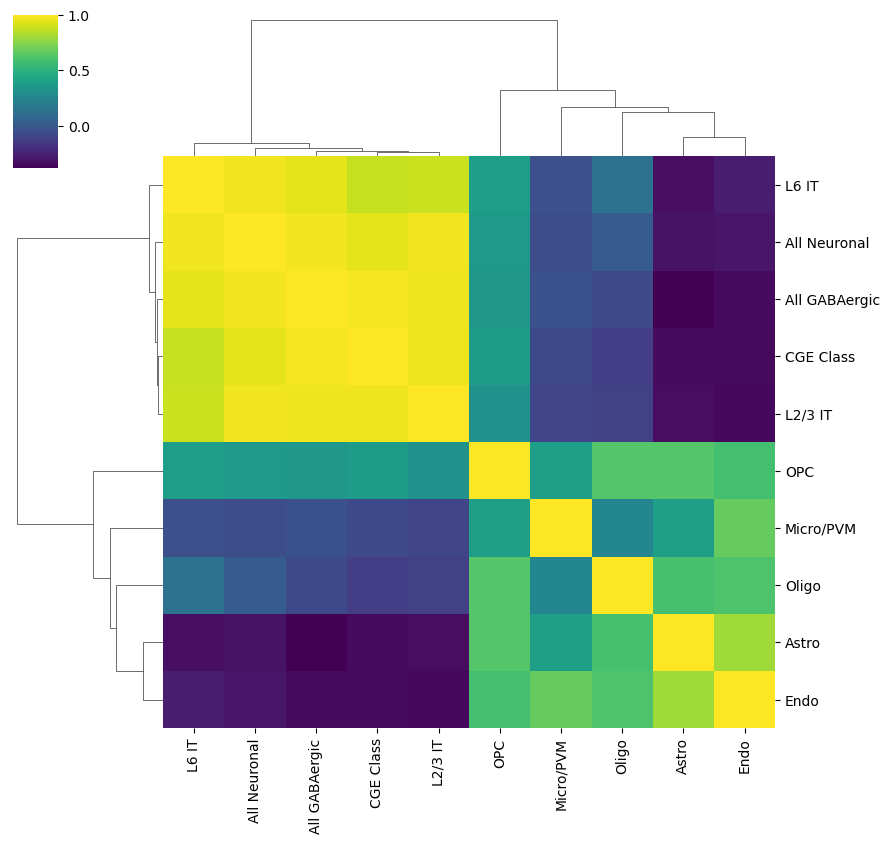

In [121]:
expr_corr_mat = expr_corr_df.corr()
sns.clustermap(expr_corr_mat, cmap='viridis', figsize=(9, 8.5))

# Manually inspect top genes

In [127]:
cts_to_keep = []

In [122]:
expr_corr_df.columns

Index(['CGE Class', 'All GABAergic', 'Micro/PVM', 'Oligo', 'Astro', 'Endo',
       'All Neuronal', 'L6 IT', 'L2/3 IT', 'OPC'],
      dtype='object')

In [128]:
expr_corr_df.sort_values("CGE Class", ascending=False).head(25)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
DLX1,0.973527,0.918464,0.084731,-0.162782,-0.142755,-0.097956,0.695759,0.415868,0.732787,0.377844
DLX6-AS1,0.949961,0.848945,0.028569,-0.173324,-0.195719,-0.109800,0.603117,0.327529,0.719349,0.336318
PTHLH,0.949707,0.868717,0.064352,-0.171398,-0.174311,-0.121390,0.651507,0.422055,0.687445,0.379413
RGS8,0.944692,0.839300,0.012792,-0.153393,-0.156982,-0.106786,0.637766,0.343933,0.737480,0.348427
TAC3,0.933826,0.808946,0.095879,-0.212277,-0.112867,-0.091465,0.563990,0.288557,0.654601,0.367905
PRLHR,0.926379,0.873376,0.028408,-0.124533,-0.170070,-0.132019,0.672814,0.398531,0.734897,0.312875
SLC10A4,0.921331,0.841449,-0.006439,-0.107471,-0.147239,-0.119836,0.695165,0.418514,0.739924,0.329699
ELFN1,0.917128,0.842229,0.042716,-0.060431,-0.053578,-0.036271,0.671563,0.459402,0.651960,0.414274
DLX2,0.914041,0.855479,0.049778,-0.158854,-0.097237,-0.131281,0.633582,0.397532,0.633484,0.328285


In [130]:
expr_corr_df.sort_values("All GABAergic", ascending=False).head(25)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
GAD2,0.906621,0.983573,0.118541,-0.085080,-0.256868,-0.090071,0.792791,0.591199,0.702908,0.319374
GAD1,0.899586,0.983354,0.160020,-0.103781,-0.270059,-0.091579,0.795558,0.585619,0.707439,0.298792
ZNF385D,0.890694,0.976246,0.135347,0.001426,-0.190583,-0.037087,0.811622,0.682612,0.674133,0.418157
VWC2,0.879197,0.966298,0.121797,-0.034416,-0.203412,-0.066195,0.839808,0.689842,0.707190,0.387620
SLC32A1,0.881368,0.965911,0.068114,-0.113364,-0.320360,-0.152991,0.783962,0.575513,0.682584,0.224722
MYO5B,0.823901,0.965045,0.167115,-0.067614,-0.252233,-0.052385,0.802344,0.621760,0.660895,0.287381
LGI2,0.867338,0.962892,0.091875,-0.053866,-0.297147,-0.071711,0.787807,0.630017,0.662529,0.288212
BTBD11,0.910345,0.961247,0.140474,-0.110977,-0.134063,-0.077836,0.793302,0.546044,0.732196,0.353450
NXPH1,0.889254,0.956607,0.164095,-0.011692,-0.131622,-0.010969,0.752231,0.598110,0.647325,0.513577


In [131]:
expr_corr_df.sort_values("All Neuronal", ascending=False).head(25)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
DLG3,0.709528,0.841923,-0.019349,0.013993,-0.227879,-0.128760,0.986240,0.754759,0.810542,0.195802
ADD2,0.658479,0.814661,-0.000556,0.040960,-0.211003,-0.113088,0.985687,0.793453,0.781297,0.210593
SMAP2,0.699750,0.835714,0.076540,0.046832,-0.178368,-0.076955,0.983650,0.751156,0.798369,0.215937
RAB6B,0.690386,0.833131,0.030397,0.003478,-0.176850,-0.100993,0.983148,0.743738,0.802630,0.218822
SPATS2,0.655802,0.800459,0.057733,0.029383,-0.183947,-0.076134,0.982968,0.750896,0.803426,0.212211
GNB5,0.697305,0.845314,0.049229,0.017356,-0.149856,-0.076487,0.982939,0.775570,0.784948,0.239366
MAP2K4,0.660316,0.825267,0.028636,0.058589,-0.233930,-0.098147,0.982759,0.791501,0.771473,0.217994
NDRG3,0.663725,0.836523,0.056203,0.056082,-0.184723,-0.072567,0.982756,0.779524,0.759593,0.215162
STXBP1,0.634944,0.804396,-0.006763,0.022965,-0.245999,-0.138165,0.982309,0.799365,0.757398,0.142377


In [138]:
expr_corr_df.loc['RBFOX3'].sort_values(ascending=False).head()

All Neuronal     0.892079
L2/3 IT          0.723205
All GABAergic    0.711340
L6 IT            0.701633
CGE Class        0.620115
Name: RBFOX3, dtype: float64

In [139]:
expr_corr_df.loc['SNAP25'].sort_values(ascending=False).head()

All Neuronal     0.966728
L6 IT            0.817870
All GABAergic    0.816698
L2/3 IT          0.717063
CGE Class        0.627472
Name: SNAP25, dtype: float64

In [140]:
expr_corr_df.loc['SYT1'].sort_values(ascending=False).head()

All Neuronal     0.966382
L6 IT            0.861817
All GABAergic    0.805589
L2/3 IT          0.693953
CGE Class        0.598140
Name: SYT1, dtype: float64

In [141]:
expr_corr_df.loc['ENO2'].sort_values(ascending=False).head()

All Neuronal     0.973299
All GABAergic    0.797447
L6 IT            0.794959
L2/3 IT          0.713124
CGE Class        0.610585
Name: ENO2, dtype: float64

In [145]:
expr_corr_df.sort_values("L6 IT", ascending=False).head(20)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
RXFP1,0.256190,0.536398,-0.028099,0.272829,-0.308275,-0.116318,0.703492,0.962306,0.254085,0.164424
CHN2,0.313463,0.575463,0.024184,0.410023,-0.220757,-0.010956,0.733033,0.960085,0.298348,0.276035
FOXP2,0.270582,0.545364,0.078811,0.280148,-0.216698,0.003465,0.690174,0.959775,0.239027,0.258164
B3GALT2,0.397793,0.613798,-0.041999,0.355471,-0.170444,-0.033373,0.772937,0.943217,0.398352,0.351797
CHRM2,0.546095,0.762136,0.019834,0.166465,-0.298154,-0.123759,0.806255,0.936679,0.447185,0.250766
SLC24A2,0.485332,0.737973,0.015791,0.276752,-0.252220,-0.069404,0.887116,0.931870,0.518572,0.231343
SLC35F1,0.398313,0.609207,0.089756,0.340909,0.057676,0.075947,0.760639,0.927720,0.349655,0.494920
CNIH3,0.497832,0.736768,-0.020807,0.155311,-0.242185,-0.099797,0.891134,0.925418,0.519438,0.235939
DIRAS2,0.492543,0.716960,0.010896,0.160936,-0.258917,-0.096572,0.902566,0.923071,0.580383,0.195655


In [146]:
expr_corr_df.sort_values("L2/3 IT", ascending=False).head(20)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
HS6ST3,0.782425,0.793402,0.023801,-0.161251,-0.166561,-0.128010,0.876401,0.453193,0.945425,0.178778
ENSG00000234929,0.682725,0.643712,-0.055135,-0.159497,-0.172335,-0.161574,0.753921,0.327002,0.939236,0.113976
CUX2,0.758944,0.688580,0.062232,-0.257861,-0.032341,-0.061228,0.723004,0.218961,0.931695,0.165896
GRIA4,0.797390,0.825163,0.005912,-0.075001,-0.142760,-0.110380,0.903371,0.520990,0.927923,0.261711
LINC00507,0.777953,0.715285,0.006107,-0.176343,-0.127646,-0.129143,0.732456,0.298453,0.924211,0.148780
RASGRF2,0.780452,0.792048,0.035477,-0.133059,-0.187918,-0.105137,0.842637,0.417372,0.919207,0.189109
AKAP5,0.762708,0.779656,0.030907,-0.098397,-0.151208,-0.090848,0.884487,0.526323,0.912328,0.253005
LRRTM4,0.748846,0.795634,-0.014551,-0.068233,-0.171855,-0.130253,0.920676,0.558207,0.912048,0.214388
ENSG00000286662,0.679209,0.686719,0.027351,-0.107447,-0.164113,-0.115634,0.785831,0.399323,0.910578,0.146523


In [147]:
expr_corr_df.sort_values("OPC", ascending=False).head(20)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
LHFPL3,0.211680,0.164182,0.301655,0.314316,0.563280,0.465118,0.063114,0.140007,0.023504,0.940003
BCHE,0.337544,0.278291,0.184816,0.434281,0.488227,0.393021,0.150258,0.206966,0.113685,0.934474
SEMA5A,0.252191,0.289183,0.355200,0.374025,0.448626,0.509761,0.218768,0.330118,0.087296,0.920455
LUZP2,0.545789,0.521118,0.163187,0.195384,0.295383,0.248840,0.398341,0.397836,0.327503,0.905402
PLPPR1,0.353166,0.313415,0.067836,0.589419,0.377366,0.290187,0.230995,0.327345,0.136348,0.903680
PCDH15,0.253856,0.181379,0.163078,0.263030,0.493195,0.364740,0.055738,0.112663,0.056017,0.879374
PDGFRA,0.286630,0.221085,0.226654,0.275122,0.560541,0.441509,0.134198,0.132914,0.137891,0.877352
BLM,0.356609,0.381072,0.346885,0.304624,0.473355,0.457414,0.243931,0.278259,0.175938,0.840599
LINC00237,0.270739,0.255292,0.156653,0.406275,0.484352,0.396810,0.133783,0.212345,0.055203,0.836610


In [148]:
expr_corr_df.sort_values("Micro/PVM", ascending=False).head(20)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
APBB1IP,0.041431,0.131631,0.980434,0.029179,0.150872,0.450977,0.038592,0.055040,0.000462,0.202858
NCKAP1L,0.015292,0.101167,0.975720,0.021526,0.160676,0.450162,0.019136,0.026067,-0.007892,0.177800
BTK,0.017322,0.092816,0.971747,0.021120,0.194316,0.459674,0.032351,0.006388,0.032113,0.209926
LAPTM5,-0.001642,0.065932,0.971509,0.027053,0.177077,0.438154,-0.026683,-0.014138,-0.050493,0.175838
DOCK2,0.006554,0.095508,0.968024,0.036053,0.155079,0.468145,0.013980,0.041705,-0.024944,0.198330
SASH3,-0.055737,0.007498,0.967508,0.045521,0.193933,0.460293,-0.059777,-0.040573,-0.075411,0.161788
MILR1,0.058024,0.140391,0.966868,0.012583,0.126341,0.420837,0.026339,0.053267,-0.000610,0.242479
CYBB,0.013893,0.098821,0.965758,0.001361,0.118559,0.472095,0.013702,0.008825,0.004294,0.192974
TBXAS1,-0.021210,0.031431,0.965383,0.054307,0.241604,0.456243,-0.040580,-0.045911,-0.045863,0.173136


In [149]:
expr_corr_df.sort_values("Endo", ascending=False).head(20)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
TGFBR2,-0.096594,-0.062423,0.578057,0.284558,0.425590,0.964269,-0.091640,-0.031265,-0.127415,0.429230
MYCT1,-0.036589,-0.061735,0.355581,0.337351,0.415978,0.949421,-0.076110,-0.037571,-0.088992,0.432996
CYYR1,-0.170835,-0.161160,0.355236,0.310563,0.540053,0.942391,-0.141270,-0.081365,-0.181370,0.405293
MECOM,-0.136299,-0.111411,0.428048,0.262184,0.389014,0.942381,-0.107009,-0.057864,-0.149598,0.319398
FOXC1,-0.113584,-0.104474,0.386764,0.247420,0.396073,0.937727,-0.112280,-0.078999,-0.140138,0.314447
PRKCH,-0.102294,-0.070576,0.442953,0.381423,0.511412,0.931990,-0.027626,0.023580,-0.099716,0.425892
FLI1,-0.083458,-0.024726,0.641848,0.302395,0.418586,0.922967,-0.027063,0.022611,-0.096816,0.409941
ABCB1,-0.085472,-0.070641,0.424654,0.304454,0.479804,0.919801,-0.059944,-0.021994,-0.090032,0.425091
ESAM,-0.073430,-0.042448,0.362351,0.421161,0.506496,0.912187,0.002737,0.040038,-0.104956,0.393321


In [150]:
expr_corr_df.loc['CLDN5'].sort_values(ascending=False).head()

Endo         0.760043
Astro        0.582317
Oligo        0.365898
Micro/PVM    0.273342
OPC          0.248457
Name: CLDN5, dtype: float64

In [152]:
expr_corr_df.loc['NOSTRIN'].sort_values(ascending=False).head()

Endo         0.799552
Astro        0.602318
Micro/PVM    0.422386
Oligo        0.336288
OPC          0.304222
Name: NOSTRIN, dtype: float64

In [154]:
expr_corr_df.loc['PECAM1'].sort_values(ascending=False).head()

Endo         0.817276
Micro/PVM    0.442746
Astro        0.427601
Oligo        0.319104
OPC          0.188490
Name: PECAM1, dtype: float64

In [155]:
expr_corr_df.loc['FLT1'].sort_values(ascending=False).head()

Endo         0.746829
Micro/PVM    0.447571
Astro        0.430574
OPC          0.360756
Oligo        0.240917
Name: FLT1, dtype: float64

In [156]:
expr_corr_df.sort_values("Astro", ascending=False).head(20)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
MSI2,-0.138530,-0.238404,0.158546,0.169596,0.967714,0.453812,-0.178912,-0.242812,-0.095168,0.430831
PON2,-0.207421,-0.312959,0.221167,0.262636,0.964804,0.475325,-0.298384,-0.295499,-0.228827,0.434983
S1PR1,-0.170307,-0.287791,0.132985,0.191944,0.961609,0.491645,-0.226322,-0.263935,-0.158218,0.428212
GPR137B,-0.079949,-0.190162,0.159808,0.240485,0.958797,0.435602,-0.148426,-0.215243,-0.079449,0.493542
PPARA,-0.137011,-0.245213,0.188434,0.209211,0.958724,0.470627,-0.206723,-0.242625,-0.123442,0.506945
NPAS3,-0.161440,-0.259786,0.151554,0.275894,0.957173,0.445181,-0.200874,-0.236964,-0.144427,0.436123
SDC2,-0.153136,-0.260431,0.139892,0.156083,0.955264,0.376994,-0.215207,-0.254932,-0.147438,0.414641
ELP4,-0.046224,-0.128748,0.215638,0.245877,0.953026,0.495331,-0.059634,-0.126166,-0.012781,0.549557
PITPNC1,-0.047427,-0.119268,0.214063,0.170528,0.951339,0.447142,-0.081638,-0.149530,-0.034684,0.493684


In [163]:
expr_corr_df.loc['SLC1A3'].sort_values(ascending=False).head()

Astro        0.883993
Endo         0.329289
OPC          0.249949
Micro/PVM    0.194412
Oligo        0.066923
Name: SLC1A3, dtype: float64

In [165]:
expr_corr_df.sort_values("Oligo", ascending=False).head(20)

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,L6 IT,L2/3 IT,OPC
Gene,,,,,,,,,,
MOG,-0.174040,-0.053098,0.063672,0.980340,0.212182,0.294256,0.045831,0.305185,-0.182506,0.369426
TMEM88B,-0.202094,-0.092923,0.001909,0.968294,0.212997,0.267893,0.007176,0.283343,-0.220521,0.382751
MYRF,-0.221393,-0.104674,0.049389,0.965308,0.224358,0.285655,0.015177,0.249119,-0.203273,0.285045
MAG,-0.190898,-0.066877,0.001904,0.961333,0.145135,0.227783,0.056701,0.317469,-0.189468,0.271419
EVI2A,-0.148215,-0.049525,0.092072,0.959960,0.262830,0.370264,0.021064,0.269214,-0.169425,0.459203
FOLH1,-0.205553,-0.108419,0.048272,0.959244,0.277794,0.331131,-0.039746,0.221933,-0.232077,0.408750
TMEM125,-0.068759,0.024292,-0.041279,0.958013,0.174354,0.241962,0.114027,0.341014,-0.090852,0.382922
CNP,-0.157310,-0.068441,0.067648,0.954811,0.398096,0.375132,0.050066,0.250696,-0.156158,0.457542
PLPP2,-0.216388,-0.118430,0.037035,0.953345,0.299125,0.368163,0.007729,0.237437,-0.199256,0.357884


# Save eigengenes

In [166]:
eigengene_df = eigengene_df.rename(columns={'L6 IT': 'Deep layer glutamatergic'})
eigengene_df = eigengene_df.rename(columns={'L2/3 IT': 'Upper layer glutamatergic'})

In [167]:
eigengene_df.head()

,CGE Class,All GABAergic,Micro/PVM,Oligo,Astro,Endo,All Neuronal,Deep layer glutamatergic,Upper layer glutamatergic,OPC
GTEX.13FHO.0011.R10b.SM.5J2MM,-0.050080,-0.044075,-0.014197,-0.016812,0.053503,0.039962,0.036849,0.045532,-0.022012,-0.014980
GTEX.13JUV.0011.R10b.SM.5LZXR,0.010140,0.000195,0.009498,-0.052329,0.051857,-0.024269,-0.056602,-0.050377,-0.054703,0.004546
GTEX.13N1W.0011.R10b.SM.5MR4H,-0.030265,-0.037236,-0.055017,0.054247,-0.071606,-0.050470,0.007093,0.015361,-0.025940,-0.083530
GTEX.16XZZ.0011.R10b.SM.7LT91,0.003977,-0.055267,0.078768,-0.067533,0.050665,0.019300,0.000287,-0.083767,0.141548,-0.071513
GTEX.17JCI.0011.R10b.SM.718A2,0.014534,-0.011248,-0.015789,-0.024048,-0.031594,-0.017101,0.018281,-0.004229,0.105404,-0.035343


In [ ]:
eigengene_df.to_csv("data/GTEx_frontal_cortex_counts_TMMF_All_200_outliers_removed_ct_eigengenes.csv")